# Datasets EDA

we load all project datasets via `UnifiedDatasetLoader` and performs basic eda:
- dataset size and split summary
- number of classes / label dimensions
- class imbalance and label frequency
- example samples with labels


In [6]:
import subprocess
import sys
from pathlib import Path

current = Path.cwd().resolve()
if (current / 'requirements.txt').exists():
    repo_root = current
elif (current.parent / 'requirements.txt').exists():
    repo_root = current.parent
else:
    raise RuntimeError('Could not locate requirements.txt from current working directory.')

requirements_file = repo_root / 'requirements.txt'
print(f'Installing dependencies from: {requirements_file}')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(requirements_file)])
print('Dependency installation complete.')
print('If torch/torchvision were updated, restart the kernel before running the next cells.')


Installing dependencies from: C:\Users\sofia\OneDrive\Desktop\Project_Master_2\Group07_Improving_Metrics\requirements.txt
Dependency installation complete.
If torch/torchvision were updated, restart the kernel before running the next cells.


In [1]:
import torch, torchvision
print(torch.__version__, torchvision.__version__)


2.11.0+cpu 0.26.0+cpu


In [ ]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

CURRENT = Path.cwd().resolve()
if (CURRENT / 'Datasets').exists():
    REPO_ROOT = CURRENT
elif (CURRENT.parent / 'Datasets').exists():
    REPO_ROOT = CURRENT.parent


if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from Datasets.unified_dataset_loader import make_default_loader

plt.style.use('ggplot')
pd.set_option('display.max_colwidth', 120)
print(f'Repo root: {REPO_ROOT}')


In [ ]:
DATASET_ROOT = REPO_ROOT / 'data'
print(f'Using dataset root: {DATASET_ROOT}')

DATASET_CONFIGS = [
    {
        'name': 'mnist',
        'data_root': str(DATASET_ROOT / 'MNIST'),
        'image_size': 32,
        'download_train': True,
        'download_test': True,
    },
    {
        'name': 'cifar10',
        'data_root': str(DATASET_ROOT / 'CIFAR10'),
        'image_size': 32,
        'download_train': True,
        'download_test': True,
    },
    {
        'name': 'celeba',
        'data_root': str(DATASET_ROOT / 'CelebA'),
        'image_size': 64,
        'download_train': True,
        'download_test': True,
    }
]
"""
,
    {
        'name': 'chestxray14',
        'data_root': str(DATASET_ROOT / 'ChestXray14'),
        'image_size': 64,
        'download_train': False,
        'download_test': False,
    },"""


def load_dataset_pair(config: dict):
    loader = make_default_loader(
        dataset_name=config['name'],
        data_root=config['data_root'],
        image_size=config['image_size'],
    )

    try:
        train_ds = loader.get_dataset(train=True, download=False)
        test_ds = loader.get_dataset(train=False, download=False)
        return train_ds, test_ds
    except (FileNotFoundError, RuntimeError) as exc:
        print(f"{config['name']}: local load failed ({exc})")
        print(f"{config['name']}: falling back to download/setup")
        train_ds = loader.get_dataset(train=True, download=config['download_train'])
        test_ds = loader.get_dataset(train=False, download=config['download_test'])
        return train_ds, test_ds


loaded = {}
failed = {}
for cfg in DATASET_CONFIGS:
    if not isinstance(cfg, dict):
        print(f'[SKIP] Invalid dataset config entry (expected dict): {cfg!r}')
        continue

    name = cfg.get('name', '<unknown>')
    try:
        train_ds, test_ds = load_dataset_pair(cfg)
        loaded[name] = {'train': train_ds, 'test': test_ds, 'config': cfg}
        print(f'[OK] {name}: train={len(train_ds):,}, test={len(test_ds):,}')
    except Exception as exc:
        failed[name] = str(exc)
        print(f'[FAILED] {name}: {exc}')

if failed:
    print('\nDatasets that could not be loaded in this run:')
    for name, message in failed.items():
        print(f'- {name}: {message}')


NameError: name 'REPO_ROOT' is not defined

In [ ]:
def infer_class_names(dataset, dataset_name: str):
    # get class/label names from dataset-specific attributes
    if hasattr(dataset, 'classes') and dataset.classes is not None:
        classes = list(dataset.classes)
        if len(classes) > 0:
            return [str(x) for x in classes]

    if dataset_name == 'celeba' and hasattr(dataset, 'attr_names'):
        attr_names = list(dataset.attr_names)
        if len(attr_names) > 0:
            return [str(x) for x in attr_names]

    if hasattr(dataset, 'finding_classes'):
        finding_classes = list(dataset.finding_classes)
        if len(finding_classes) > 0:
            return [str(x) for x in finding_classes]

    if hasattr(dataset, 'class_to_idx') and isinstance(dataset.class_to_idx, dict):
        ordered = sorted(dataset.class_to_idx.items(), key=lambda item: item[1])
        return [str(name) for name, _ in ordered]

    return []


def target_to_numpy(target):
    if isinstance(target, torch.Tensor):
        return target.detach().cpu().numpy()
    if isinstance(target, np.ndarray):
        return target
    if isinstance(target, (list, tuple)):
        return np.asarray(target)
    return np.asarray(target)


def parse_target(target):
    # detecting single-label vs multi-label targets and return label indices
    arr = target_to_numpy(target)
    if arr.ndim == 0:
        return 'single', [int(arr.item())]

    flat = arr.reshape(-1)
    if flat.size == 1:
        return 'single', [int(flat[0])]

    positives = np.where(flat > 0)[0].tolist()
    return 'multi', positives


def collect_label_stats(dataset, max_samples: int = 20000):
    # counting label frequencies 
    limit = min(len(dataset), max_samples)
    if limit == 0:
        raise ValueError('Dataset has zero samples.')

    mode = None
    counter = Counter()

    for idx in range(limit):
        _, target = dataset[idx]
        current_mode, labels = parse_target(target)
        if mode is None:
            mode = current_mode

        if mode == 'single':
            counter[labels[0]] += 1
        else:
            for label_idx in labels:
                counter[label_idx] += 1

    return {'mode': mode, 'counts': counter, 'sampled': limit}


def imbalance_ratio(counts):
    # computing max/min ratio across  class counts
    non_zero = [int(x) for x in counts if int(x) > 0]
    if not non_zero:
        return float('nan')
    return max(non_zero) / min(non_zero)


In [6]:
summary_rows = []
label_stats = {}

for name, entry in loaded.items():
    train_ds = entry['train']
    test_ds = entry['test']
    class_names = infer_class_names(train_ds, name)

    train_stats = collect_label_stats(train_ds, max_samples=20000)
    label_stats[name] = train_stats

    if train_stats['mode'] == 'single':
        class_count_estimate = max(train_stats['counts'].keys(), default=-1) + 1
        class_count = len(class_names) if class_names else class_count_estimate
        count_vector = [train_stats['counts'].get(i, 0) for i in range(class_count)]
        ratio = imbalance_ratio(count_vector)
    else:
        class_count_estimate = max(train_stats['counts'].keys(), default=-1) + 1
        class_count = len(class_names) if class_names else class_count_estimate
        count_vector = [train_stats['counts'].get(i, 0) for i in range(class_count)]
        ratio = imbalance_ratio(count_vector)

    summary_rows.append({
        'dataset': name,
        'train_samples': len(train_ds),
        'test_samples': len(test_ds),
        'label_mode': train_stats['mode'],
        'class_count_or_label_dim': class_count,
        'samples_used_for_stats': train_stats['sampled'],
        'imbalance_ratio_max_div_min_nonzero': round(float(ratio), 3) if not np.isnan(ratio) else np.nan,
    })

summary_df = pd.DataFrame(summary_rows).sort_values('dataset').reset_index(drop=True)
summary_df


,dataset,train_samples,test_samples,label_mode,class_count_or_label_dim,samples_used_for_stats,imbalance_ratio_max_div_min_nonzero
0,cifar10,50000,10000,single,10,20000,1.061
1,mnist,60000,10000,single,10,20000,1.285



MNIST - class distribution (train):


,label,count
1,1 - one,2281
7,7 - seven,2093
3,3 - three,2076
9,9 - nine,2014
0,0 - zero,1994
6,6 - six,1971
4,4 - four,1945
2,2 - two,1929
8,8 - eight,1922
5,5 - five,1775


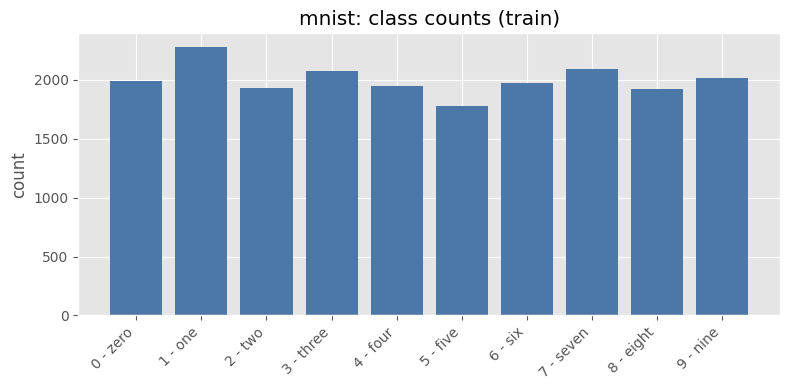


CIFAR10 - class distribution (train):


,label,count
2,bird,2042
6,frog,2038
7,horse,2027
8,ship,2012
3,cat,2011
4,deer,2009
0,airplane,1989
1,automobile,1981
9,truck,1966
5,dog,1925


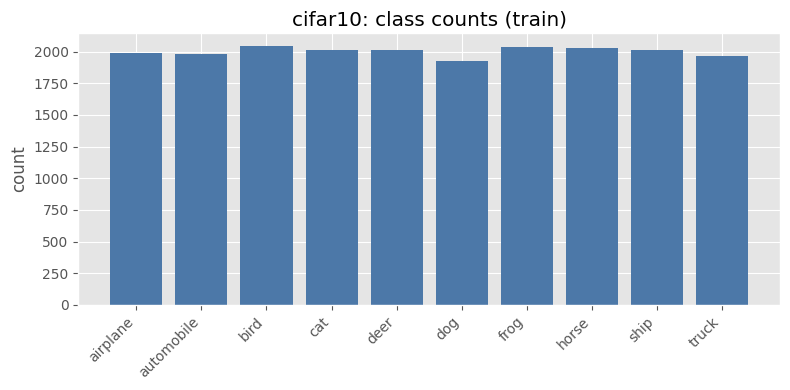

In [7]:
for name, entry in loaded.items():
    train_ds = entry['train']
    class_names = infer_class_names(train_ds, name)
    stats = label_stats[name]

    if stats['mode'] == 'single':
        class_count = len(class_names) if class_names else max(stats['counts'].keys(), default=-1) + 1
        indices = list(range(class_count))
        values = [stats['counts'].get(i, 0) for i in indices]
        labels = class_names if class_names else [str(i) for i in indices]

        dist_df = pd.DataFrame({'label': labels, 'count': values}).sort_values('count', ascending=False)

        print(f'\n{name.upper()} - class distribution (train):')
        display(dist_df.head(20))

        plt.figure(figsize=(max(8, min(16, class_count * 0.5)), 4))
        plt.bar(labels, values, color='#4C78A8')
        plt.title(f'{name}: class counts (train)')
        plt.ylabel('count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    else:
        class_count = len(class_names) if class_names else max(stats['counts'].keys(), default=-1) + 1
        indices = list(range(class_count))
        values = [stats['counts'].get(i, 0) for i in indices]
        labels = class_names if class_names else [f'label_{i}' for i in indices]

        dist_df = pd.DataFrame({
            'label': labels,
            'positive_count': values,
            'positive_rate': np.asarray(values, dtype=np.float64) / stats['sampled'],
        }).sort_values('positive_count', ascending=False)

        print(f'\n{name.upper()} - multi-label frequency (train):')
        display(dist_df)

        plt.figure(figsize=(max(10, min(16, class_count * 0.35)), 4))
        plt.bar(labels, values, color='#F58518')
        plt.title(f'{name}: positive label counts (train)')
        plt.ylabel('positive count')
        plt.xticks(rotation=60, ha='right')
        plt.tight_layout()
        plt.show()



MNIST - class names / labels:
['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


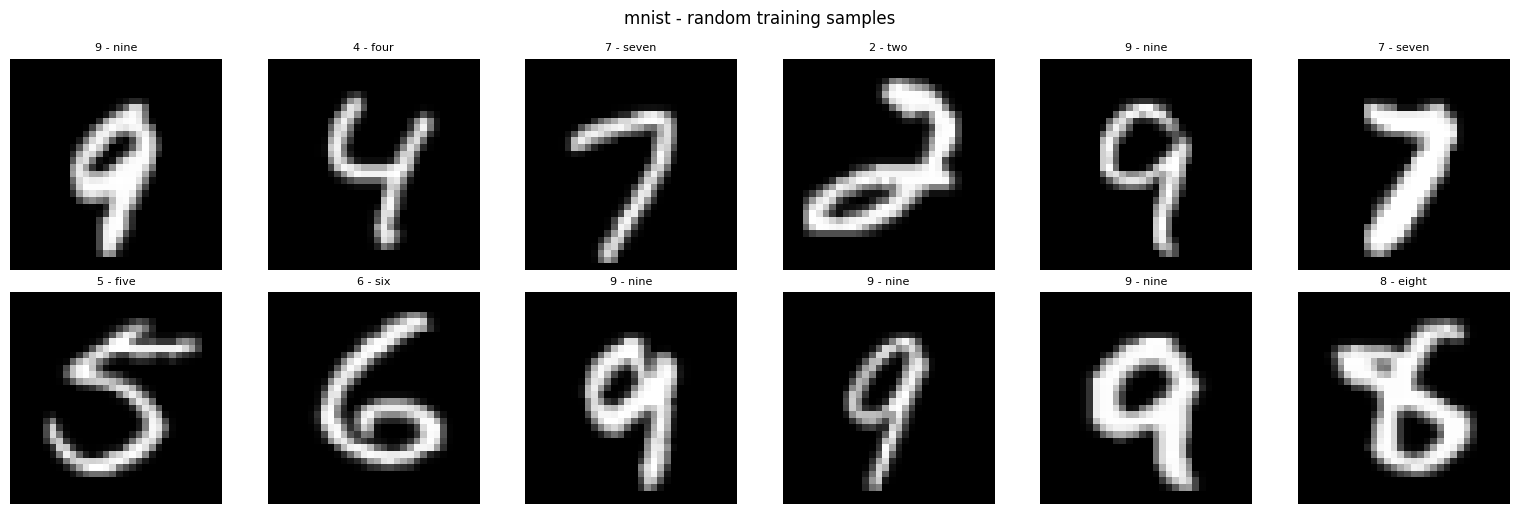


CIFAR10 - class names / labels:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


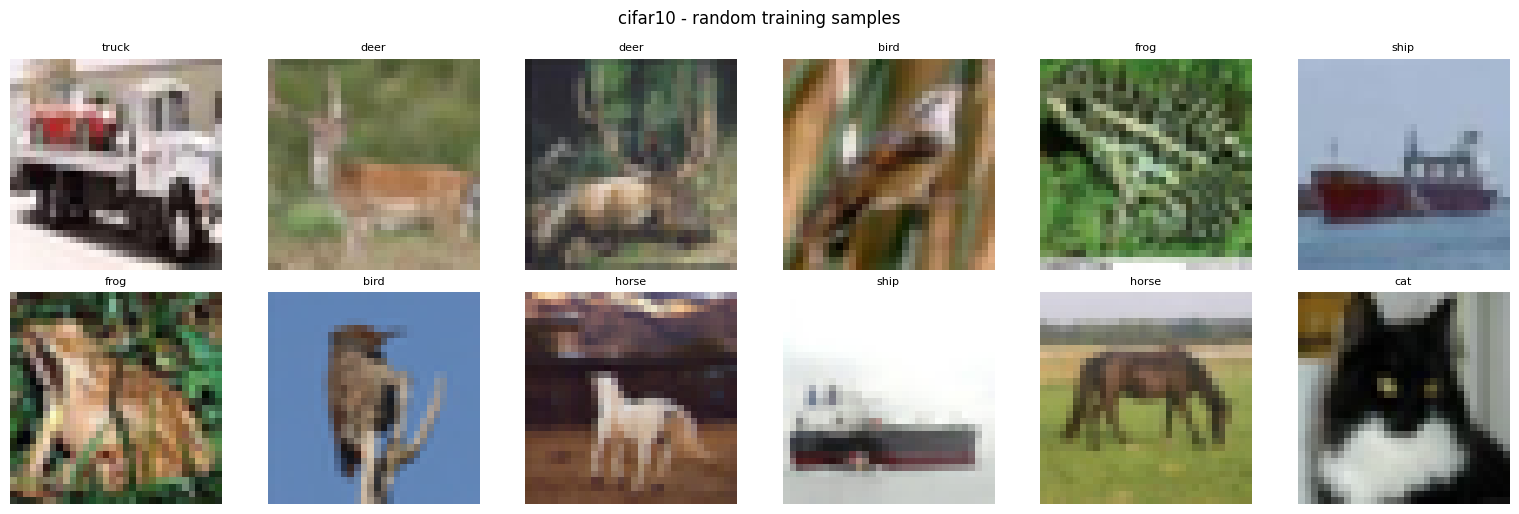

In [ ]:
def image_for_plot(image):
    #  image data converted to a rray in [0, 1].
    if isinstance(image, torch.Tensor):
        arr = image.detach().cpu().float()
        if arr.ndim == 3 and arr.shape[0] in (1, 3):
            arr = arr.permute(1, 2, 0)
        arr = arr.numpy()
    else:
        arr = np.asarray(image)

    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr[..., 0]

    if arr.ndim == 3 and arr.shape[-1] in (1, 3):
        if arr.min() < 0:
            arr = (arr + 1.0) / 2.0
        arr = np.clip(arr, 0.0, 1.0)
        return arr, None

    if arr.ndim == 2:
        if arr.min() < 0:
            arr = (arr + 1.0) / 2.0
        arr = np.clip(arr, 0.0, 1.0)
        return arr, 'gray'

    return arr, None


def format_target_text(target, class_names, max_labels: int = 3):
    # target labels for plot titles
    mode, labels = parse_target(target)
    if mode == 'single':
        idx = labels[0]
        if 0 <= idx < len(class_names):
            return class_names[idx]
        return str(idx)

    if not labels:
        return 'No Finding / None'

    names = []
    for idx in labels:
        if 0 <= idx < len(class_names):
            names.append(class_names[idx])
        else:
            names.append(str(idx))

    if len(names) <= max_labels:
        return ', '.join(names)

    head = ', '.join(names[:max_labels])
    return f'{head}, +{len(names) - max_labels} more'


def show_examples(dataset, dataset_name: str, class_names: list[str], n: int = 12, cols: int = 6, seed: int = 10):
    # geeting radnom samples to see
    random.seed(seed)
    count = min(n, len(dataset))
    idxs = random.sample(range(len(dataset)), count)

    rows = int(np.ceil(count / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.6, rows * 2.6))
    axes = np.atleast_1d(axes).reshape(rows, cols)

    for plot_idx, sample_idx in enumerate(idxs):
        r, c = divmod(plot_idx, cols)
        ax = axes[r, c]

        image, target = dataset[sample_idx]
        arr, cmap = image_for_plot(image)
        ax.imshow(arr, cmap=cmap)
        ax.set_title(format_target_text(target, class_names), fontsize=8)
        ax.axis('off')

    for empty_idx in range(count, rows * cols):
        r, c = divmod(empty_idx, cols)
        axes[r, c].axis('off')

    fig.suptitle(f'{dataset_name} - random training samples', fontsize=12)
    plt.tight_layout()
    plt.show()


for name, entry in loaded.items():
    class_names = infer_class_names(entry['train'], name)
    print(f'\n{name.upper()} - class names / labels:')
    if class_names:
        print(class_names)
    else:
        print('No explicit class-name list found.')

    show_examples(entry['train'], name, class_names, n=12, cols=6, seed=42)


## Notes
- `chestxray14` uses the local setup generated by `Scripts/download_preprocess_chestxray14.py`.
- If a dataset fails to load, check credentials/download setup and re-run the load cell.
